# Lab 7: Morphological Transformations, Hough Line Transform, and Hough Circle Transform in OpenCV
This lab focuses on applying morphological transformations, Hough Line Transform, and Hough Circle Transform using OpenCV. The exercises cover image preprocessing with morphological operations, detecting lines, and detecting circles. Code is designed for a Jupyter Notebook, with images displayed inline using matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Exercise 1: Morphological Transformations
Task: Apply erosion, dilation, opening, and closing to a binary image.

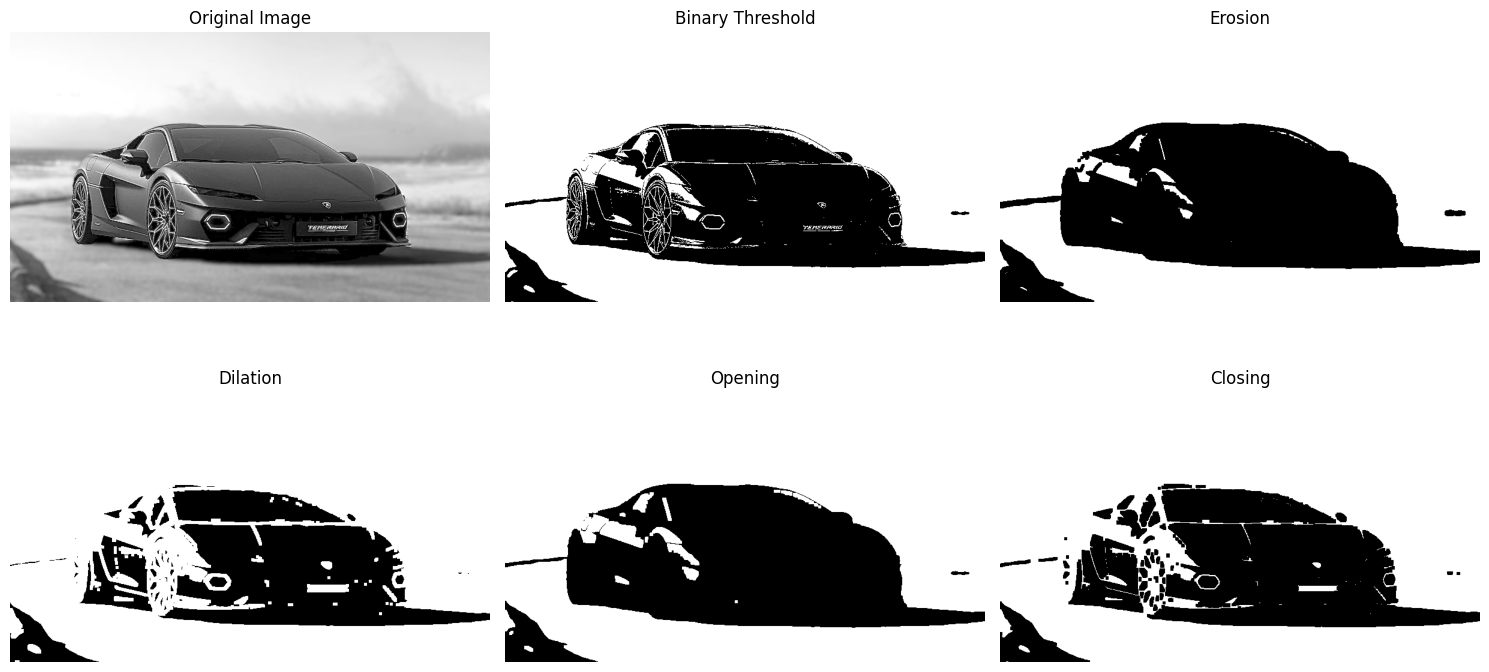

In [2]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply binary threshold
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Define kernel
kernel = np.ones((5, 5), np.uint8)

# Apply morphological transformations
erosion = cv2.erode(thresh, kernel, iterations=1)
dilation = cv2.dilate(thresh, kernel, iterations=1)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Binary Threshold')
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Erosion')
plt.imshow(erosion, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title('Dilation')
plt.imshow(dilation, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title('Opening')
plt.imshow(opening, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title('Closing')
plt.imshow(closing, cmap='gray')
plt.axis('off')

plt.tight_layout()

## Exercise 2: Hough Line Transform
Task: Detect lines in an image using the Hough Line Transform.

(-0.5, 799.5, 449.5, -0.5)

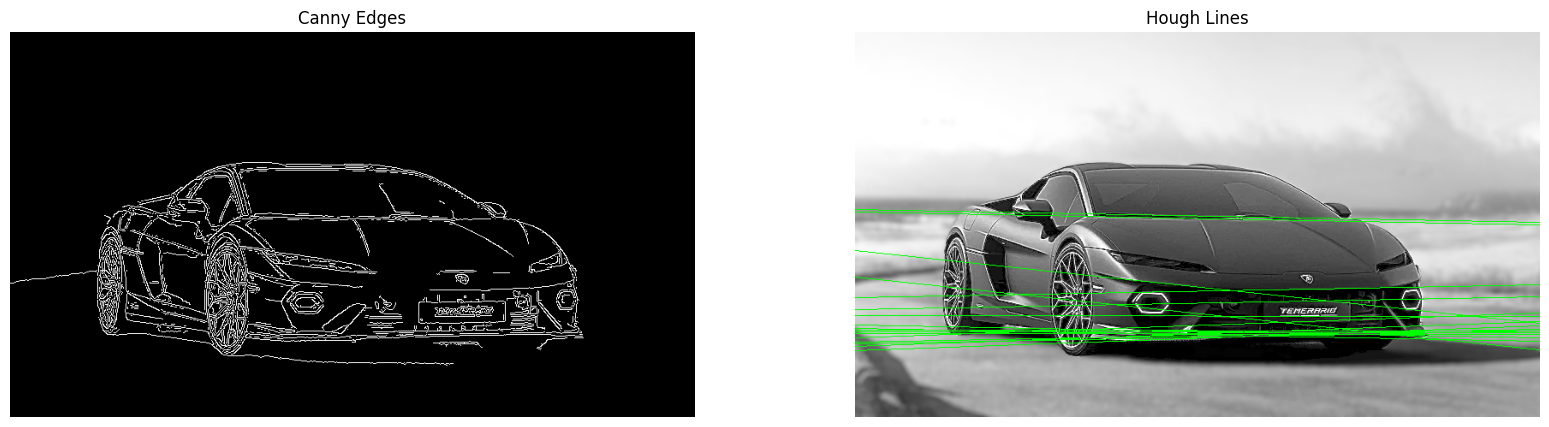

In [3]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply Canny edge detection
edges = cv2.Canny(img, 100, 200)

# Apply Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=150)

# Draw lines on color image
img_lines = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 1)

# Display results
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Hough Lines')
plt.imshow(img_lines)
plt.axis('off')

## Exercise 3: Hough Circle Transform
Task: Detect circles (e.g., wheels) in an image using the Hough Circle Transform.

(-0.5, 799.5, 449.5, -0.5)

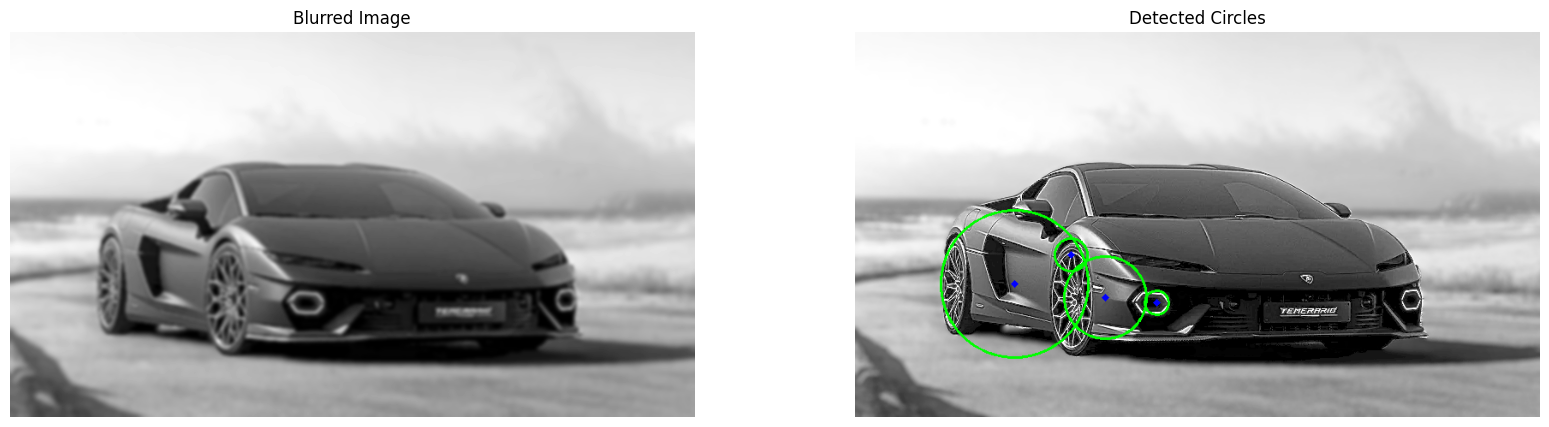

In [4]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply Gaussian blur to reduce noise
img_blur = cv2.GaussianBlur(img, (9, 9), 2)

# Apply Hough Circle Transform
circles = cv2.HoughCircles(img_blur, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
                          param1=200, param2=30, minRadius=10, maxRadius=100)

# Draw circles on color image
img_circles = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # Draw circle and center
        cv2.circle(img_circles, (i[0], i[1]), i[2], (0, 255, 0), 2)
        cv2.circle(img_circles, (i[0], i[1]), 2, (0, 0, 255), 3)

# Display results
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title('Blurred Image')
plt.imshow(img_blur, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Detected Circles')
plt.imshow(img_circles)
plt.axis('off')

# By **Saddam Umer**

BS AI, SMIU